## Import

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os 

import anndata as ad
import scanpy as sc

## Manual loading and preprocessing data

In [9]:
# function to load the data from one or several slices
def load_data(data_dir, file_names=None, all_files=False):
    if all_files:
        files_all = [f for f in sorted(os.listdir(data_dir)) if f.endswith('.h5ad')]
    else:
        files_all = file_names
    if len(file_names)==1:
        adatas = sc.read_h5ad(os.path.join(data_dir, file_names[0]))
        # ensure spatial coordinates are in obsm['spatial']
        if 'spatial' not in adatas.obsm:
            adatas.obsm['spatial'] = adatas.obs[['x', 'y']].to_numpy()
    else:
        adatas = []
        for file in files_all:
            #slice_name = file.replace('.h5ad', '')
            adata = sc.read_h5ad(os.path.join(data_dir, file))
            #adata.obs_names = [f"{slice_name}_{x}" for x in adata.obs_names]
            #adata.obs['slice'] = slice_name
            adatas.append(adata)
            #combined_adata = sc.concat(adatas.values(), label='slice', keys=list(adatas.keys()))
            if 'spatial' not in adata.obsm:
                 adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
    return adatas

In [29]:
#compute QC metrics and visualize
def visualize_for_preprocess(adata):
    #compute percent_mt and qc metrics
    adata.var["mt"] = adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    #visualize
    fig, axs = plt.subplots(1, 4, figsize=(15, 4))
    sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
    sns.histplot(adata.obs["total_counts"][adata.obs["total_counts"] < 10000], kde=False, bins=40, ax=axs[1])
    sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])
    sns.histplot(adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000], kde=False, bins=60, ax=axs[3])
    plt.show()
    return 

In [12]:
def preprocess_one_adata(adata, min_counts=100, min_cells=1, n_top_genes=200):
    #filtering of cells with too much counts or too high expression of mt genes,
    #filtering of genes that are expressed in less than 10 cells
    sc.pp.filter_cells(adata, min_counts=min_counts)
    #combined_adata = combined_adata[combined_adata.obs.pct_counts_mt < 20]
    sc.pp.filter_genes(adata, min_cells=min_cells)

    #save raw counts to a layer
    adata.layers['counts'] = adata.X.copy()

    #calculate Pearson residuals
    sc.experimental.pp.normalize_pearson_residuals(adata)

    #save Pearson residuals to a layer
    adata.layers['residuals'] = adata.X.copy()

    def pearson_highly_variable_genes(adata, n_top_genes=n_top_genes):
        adata.var['residual_variances'] = np.var(adata.X, axis=0).T
        hv_genes = adata.var\
            .sort_values(by='residual_variances', ascending=False)\
            .head(n_top_genes).index
        adata.var['highly_variable'] = False
        adata.var.loc[hv_genes, 'highly_variable'] = True
        return

    #find highly variable genes using Pearson residuals
    pearson_highly_variable_genes(adata)

    return

In [13]:
# Load and preprocess each slice independently 
def preprocess_several_adata(adatas, slice_files, min_counts=100, min_cells=10, n_top_genes=2000):
    ads=[]
    for adata in adatas:
        # QC per slice
        adata.var["mt"] = adata.var_names.str.startswith("mt-")
        sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
        sc.pp.filter_cells(adata, min_counts=min_counts)
        sc.pp.filter_genes(adata, min_cells=min_cells)
        
        # Save raw counts before any normalization
        adata.layers['counts'] = adata.X.copy()
        
        ads.append(adata)
    
    # Merge on gene intersection 
    adata_merged = ad.concat(
        ads,
        label="batch",
        keys=slice_files,
        join="inner")
    
    # HVG on raw counts, per batch 
    sc.experimental.pp.highly_variable_genes(
        adata_merged,
        n_top_genes=n_top_genes,
        batch_key="batch",
        flavor="pearson_residuals",
        layer="counts"
    )
    
    # Pearson residuals on merged object 
    sc.experimental.pp.normalize_pearson_residuals(adata_merged, layer="counts")
    adata_merged.layers['residuals'] = adata_merged.X.copy()
    
    # Sanity checks 
    print("Total cells:", adata_merged.n_obs)
    print("Total genes:", adata_merged.n_vars)
    print("HVGs:", adata_merged.var['highly_variable'].sum())
    print("Batch counts:\n", adata_merged.obs['batch'].value_counts())
    print("Spatial coords shape:", adata_merged.obsm["spatial"].shape)
    
    coords_s1 = adata_merged[adata_merged.obs["batch"] == "sample_1"].obsm["spatial"]
    coords_s2 = adata_merged[adata_merged.obs["batch"] == "sample_2"].obsm["spatial"]
    print("Slice 1 coord range x:", coords_s1[:, 0].min(), "—", coords_s1[:, 0].max())
    print("Slice 2 coord range x:", coords_s2[:, 0].min(), "—", coords_s2[:, 0].max())
    return adata_merged

In [23]:
data_dir="/app/data/"
slice_files = ["T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad", "T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"]

In [27]:
! pwd

/app/work/processed_slices


In [5]:
#! mkdir processed_slices

In [20]:
#%cd work

/app/work


In [21]:
%cd processed_slices

/app/work/processed_slices


In [25]:
sorted(os.listdir(data_dir))

['.DS_Store',
 '.ipynb_checkpoints',
 'T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad',
 'T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad',
 'T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1092_MT63_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered.h5ad']

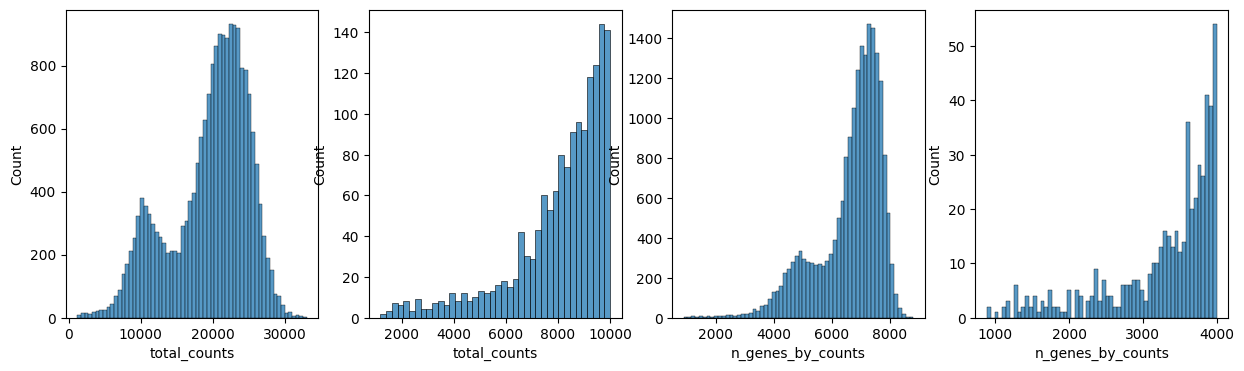

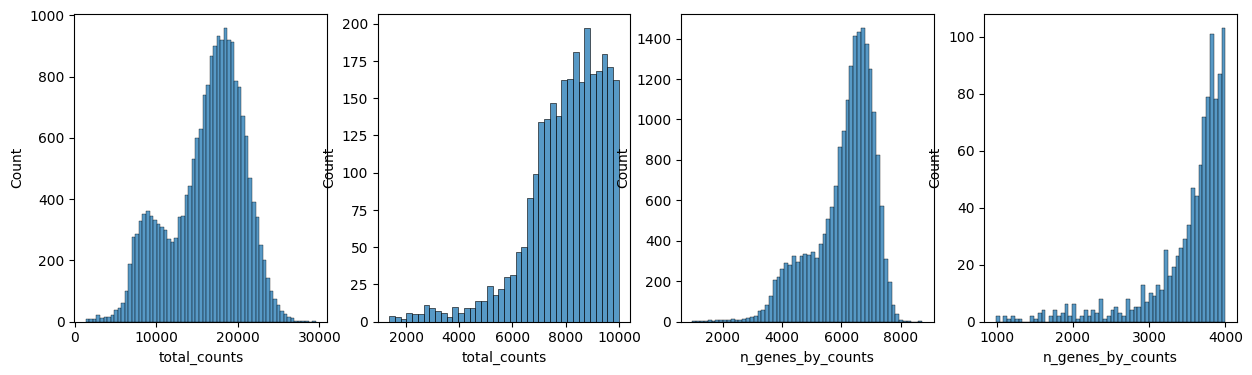

In [ ]:
#preprocess all slices separetely
for sl in sorted(os.listdir(data_dir)):
    if sl.endswith(".h5ad"):
        adata = load_data(data_dir, file_names=[sl])
        print(sl)
        visualize_for_preprocess(adata)
        preprocess_one_adata(adata)
        sc.write("Processed_"+sl, adata)

In [ ]:
#preprocess several slices simultaneously
data_dir = "app/data/"
slice_files = ["T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad", "T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad"]

adatas = load_data(data_dir, file_names=slice_files)
adata_merged = preprocess_several_adata(adatas, slice_files)

sc.write("Processed_2p0slices.h5ad", adata_merged)

## Preprocessing and saving all selected slices

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
from typing import List, Optional, Tuple
import anndata as ad
import scanpy as sc

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


In [2]:
# ============================================================================
# DATA LOADING FUNCTIONS
# ============================================================================

def load_data(data_dir: str, file_name: str):
    """
    Load a single .h5ad file from a directory.
    
    Args:
        data_dir: Directory containing the .h5ad file
        file_name: Name of the file to load
    
    Returns:
        AnnData object
    """
    filepath = os.path.join(data_dir, file_name)
    logger.info(f"Loading {filepath}")
    adata = sc.read_h5ad(filepath)
    
    # Ensure spatial coordinates are in obsm['spatial']
    if 'spatial' not in adata.obsm:
        if 'x' in adata.obs.columns and 'y' in adata.obs.columns:
            adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()
        else:
            logger.warning(f"No spatial coordinates found for {file_name}")
            adata.obsm['spatial'] = np.zeros((adata.n_obs, 2))
    
    # Add file name to obs for tracking
    adata.obs['sample_id'] = file_name.replace('.h5ad', '')
    
    return adata

def get_sample_name(file_name: str) -> str:
    """Extract sample name from filename."""
    return file_name.replace('.h5ad', '')

# ============================================================================
# QUALITY CONTROL FUNCTIONS
# ============================================================================

def compute_qc_metrics(adata):
    """Compute and add QC metrics to AnnData object"""
    # Add mitochondrial gene annotation
    adata.var["mt"] = adata.var_names.str.startswith("mt-")
    
    # Calculate QC metrics
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    
    logger.info(f"QC metrics computed for {adata.n_obs} cells")
    logger.info(f"Mean counts per cell: {adata.obs['total_counts'].mean():.2f}")
    logger.info(f"Mean genes per cell: {adata.obs['n_genes_by_counts'].mean():.2f}")
    logger.info(f"Mean MT%: {adata.obs['pct_counts_mt'].mean():.2f}%")
    
    return adata

def visualize_qc(adata, sample_name=None, save_dir=None):
    """
    Visualize QC metrics with histograms and spatial distributions.
    """
    fig, axes = plt.subplots(2, 4, figsize=(20, 5))
    
    # Histograms
    sns.histplot(adata.obs["total_counts"], kde=True, ax=axes[0, 0])
    axes[0, 0].set_title("Total Counts Distribution")
    axes[0, 0].set_xlabel("Total Counts")
    
    sns.histplot(adata.obs["total_counts"][adata.obs["total_counts"] < 10000], 
                 kde=True, bins=50, ax=axes[0, 1])
    axes[0, 1].set_title("Total Counts (<10000)")
    axes[0, 1].set_xlabel("Total Counts")
    
    sns.histplot(adata.obs["n_genes_by_counts"], kde=True, bins=60, ax=axes[0, 2])
    axes[0, 2].set_title("Genes per Cell")
    axes[0, 2].set_xlabel("Number of Genes")
    
    sns.histplot(adata.obs["n_genes_by_counts"][adata.obs["n_genes_by_counts"] < 4000], 
                 kde=True, bins=60, ax=axes[0, 3])
    axes[0, 3].set_title("Genes per Cell (<4000)")
    axes[0, 3].set_xlabel("Number of Genes")
    
    sns.histplot(adata.obs["pct_counts_mt"], kde=True, bins=50, ax=axes[1, 0])
    axes[1, 0].set_title("Mitochondrial %")
    axes[1, 0].set_xlabel("MT %")
    
    # Spatial QC if available
    if 'spatial' in adata.obsm and adata.obsm['spatial'].shape[0] > 0:
        coords = adata.obsm['spatial']
        
        # Plot spatial distribution of total counts
        scat1 = axes[1, 1].scatter(coords[:, 0], coords[:, 1], 
                                   c=adata.obs["total_counts"], 
                                   cmap='viridis', s=5, alpha=0.7)
        axes[1, 1].set_title("Spatial: Total Counts")
        plt.colorbar(scat1, ax=axes[1, 1])
        
        # Plot spatial distribution of MT%
        scat2 = axes[1, 2].scatter(coords[:, 0], coords[:, 1], 
                                   c=adata.obs["pct_counts_mt"], 
                                   cmap='Reds', s=5, alpha=0.7)
        axes[1, 2].set_title("Spatial: MT%")
        plt.colorbar(scat2, ax=axes[1, 2])
        
        # Plot spatial distribution of genes
        scat3 = axes[1, 3].scatter(coords[:, 0], coords[:, 1], 
                                   c=adata.obs["n_genes_by_counts"], 
                                   cmap='plasma', s=5, alpha=0.7)
        axes[1, 3].set_title("Spatial: Genes")
        plt.colorbar(scat3, ax=axes[1, 3])
    
    plt.tight_layout()
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        filename = f"qc_{sample_name}.png" if sample_name else "qc_plot.png"
        save_path = os.path.join(save_dir, filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        logger.info(f"QC plot saved to {save_path}")
    
    plt.show()
    return fig

def filter_cells_and_genes(adata, min_counts=100, min_cells=1, max_mt_percent=None):
    """
    Filter cells and genes based on QC metrics.
    """
    original_cells = adata.n_obs
    original_genes = adata.n_vars
    
    # Filter cells by counts
    sc.pp.filter_cells(adata, min_counts=min_counts)
    
    # Filter cells by mitochondrial percentage (default None = no filtering, like your original)
    if max_mt_percent:
        adata = adata[adata.obs['pct_counts_mt'] < max_mt_percent].copy()
    
    # Filter genes by cell expression
    sc.pp.filter_genes(adata, min_cells=min_cells)
    
    logger.info(f"Cells: {original_cells} -> {adata.n_obs} (removed {original_cells - adata.n_obs})")
    logger.info(f"Genes: {original_genes} -> {adata.n_vars} (removed {original_genes - adata.n_vars})")
    
    return adata

# ============================================================================
# NORMALIZATION AND HVG FUNCTIONS
# ============================================================================

def compute_pearson_residuals(adata, layer='counts'):
    """Compute Pearson residuals and store them in a layer."""
    sc.experimental.pp.normalize_pearson_residuals(adata, layer=layer)
    adata.layers['residuals'] = adata.X.copy()
    return adata

def identify_highly_variable_genes_pearson(adata, n_top_genes=200):
    """Identify highly variable genes using Pearson residuals."""
    # Using adata.X like your original code (not adata.layers['residuals'])
    adata.var['residual_variances'] = np.var(adata.X, axis=0).T
    hv_genes = adata.var.sort_values(by='residual_variances', ascending=False).head(n_top_genes).index
    adata.var['highly_variable'] = False
    adata.var.loc[hv_genes, 'highly_variable'] = True
    return adata

# ============================================================================
# MAIN PREPROCESSING FUNCTIONS
# ============================================================================

def preprocess_single_sample(adata, sample_name=None, output_dir=None,
                            min_counts=100, min_cells=1, n_top_genes=2000,
                            max_mt_percent=None):
    """
    Complete preprocessing pipeline for a single sample.
    This now matches your original code exactly.
    """
    logger.info(f"=== Processing sample: {sample_name or 'Unknown'} ===")
    
    # Work directly on the adata object (no copy, like your original)
    
    # 1. Compute QC metrics
    adata.var["mt"] = adata.var_names.str.startswith("mt-")
    sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
    
    # 2. Filter cells and genes (like your original)
    sc.pp.filter_cells(adata, min_counts=min_counts)
    if max_mt_percent:
        adata = adata[adata.obs['pct_counts_mt'] < max_mt_percent].copy()
    sc.pp.filter_genes(adata, min_cells=min_cells)
    
    # 3. Save raw counts
    adata.layers['counts'] = adata.X.copy()
    
    # 4. Compute Pearson residuals
    sc.experimental.pp.normalize_pearson_residuals(adata)
    adata.layers['residuals'] = adata.X.copy()
    
    # 5. Identify HVGs (using the exact same inner function as your original)
    def pearson_highly_variable_genes(adata, n_top_genes=n_top_genes):
        adata.var['residual_variances'] = np.var(adata.X, axis=0).T
        hv_genes = adata.var.sort_values(by='residual_variances', ascending=False).head(n_top_genes).index
        adata.var['highly_variable'] = False
        adata.var.loc[hv_genes, 'highly_variable'] = True
        return
    
    pearson_highly_variable_genes(adata)
    
    # Add sample info
    if sample_name:
        adata.obs['sample'] = sample_name
        adata.uns['sample_name'] = sample_name
    
    logger.info(f"=== Completed processing {sample_name or 'sample'} ===")
    logger.info(f"Cells: {adata.n_obs}, Genes: {adata.n_vars}")
    logger.info(f"HVGs: {adata.var['highly_variable'].sum()}")
    
    # Save if output directory is provided
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        filename = f"processed_{sample_name}.h5ad" if sample_name else "processed_sample.h5ad"
        output_path = os.path.join(output_dir, filename)
        sc.write(output_path, adata)
        logger.info(f"Saved to {output_path}")
    
    return adata

def preprocess_several_adata(adatas, slice_files, min_counts=100, min_cells=10, n_top_genes=2000):
    """
    Load and preprocess each slice independently, then merge them.
    This is your original function, kept exactly as is.
    """
    ads=[]
    for adata in adatas:
        # QC per slice
        adata.var["mt"] = adata.var_names.str.startswith("mt-")
        sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
        sc.pp.filter_cells(adata, min_counts=min_counts)
        sc.pp.filter_genes(adata, min_cells=min_cells)

        # Save raw counts before any normalization
        adata.layers['counts'] = adata.X.copy()

        ads.append(adata)

    # Merge on gene intersection 
    adata_merged = ad.concat(
        ads,
        label="batch",
        keys=slice_files,
        join="inner")

    # HVG on raw counts, per batch 
    sc.experimental.pp.highly_variable_genes(
        adata_merged,
        n_top_genes=n_top_genes,
        batch_key="batch",
        flavor="pearson_residuals",
        layer="counts"
    )

    # Pearson residuals on merged object 
    sc.experimental.pp.normalize_pearson_residuals(adata_merged, layer="counts")
    adata_merged.layers['residuals'] = adata_merged.X.copy()

    # Sanity checks 
    print("Total cells:", adata_merged.n_obs)
    print("Total genes:", adata_merged.n_vars)
    print("HVGs:", adata_merged.var['highly_variable'].sum())
    print("Batch counts:\n", adata_merged.obs['batch'].value_counts())
    print("Spatial coords shape:", adata_merged.obsm["spatial"].shape)

    coords_s1 = adata_merged[adata_merged.obs["batch"] == slice_files[0]].obsm["spatial"]
    coords_s2 = adata_merged[adata_merged.obs["batch"] == slice_files[1]].obsm["spatial"]
    print("Slice 1 coord range x:", coords_s1[:, 0].min(), "—", coords_s1[:, 0].max())
    print("Slice 2 coord range x:", coords_s2[:, 0].min(), "—", coords_s2[:, 0].max())
    return adata_merged

In [6]:
data_dir = "/app/data/"
files = ['T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad',
 'T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad',
 'T1091_MT64_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1092_MT63_P32_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1098_MT69_3M_Visual_Sub-CTX_V12_b100_filtered.h5ad',
 'T1099_MT67_7M_Visual_Sub-CTX_V12_b100_filtered.h5ad']

for f in files:
    adata = load_data(data_dir, f)
    sample_name = f.replace('.h5ad', '')
    processed = preprocess_single_sample(adata, sample_name, output_dir="./processed")

2026-06-19 14:08:56,508 - INFO - Loading /app/data/T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad
2026-06-19 14:08:57,319 - INFO - === Processing sample: T1089_MT66_P0_Visual_Sub-CTX_b100_filtered ===
2026-06-19 14:09:31,555 - INFO - === Completed processing T1089_MT66_P0_Visual_Sub-CTX_b100_filtered ===
2026-06-19 14:09:31,556 - INFO - Cells: 19864, Genes: 29826
2026-06-19 14:09:31,557 - INFO - HVGs: 2000
... storing 'sample_id' as categorical
... storing 'sample' as categorical
2026-06-19 14:14:49,824 - INFO - Saved to ./processed/processed_T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad
2026-06-19 14:14:49,826 - INFO - Loading /app/data/T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad
2026-06-19 14:14:50,526 - INFO - === Processing sample: T1090_MT65_P0_Visual_Sub-CTX_b100_filtered ===
2026-06-19 14:15:08,090 - INFO - === Completed processing T1090_MT65_P0_Visual_Sub-CTX_b100_filtered ===
2026-06-19 14:15:08,091 - INFO - Cells: 20730, Genes: 29780
2026-06-19 14:15:08,091 - INFO - HV

In [7]:
data_dir = "/app/data/"
slices_files = ['T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad', 'T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad']
ads=[]
for f in slices_files:
    adata = load_data(data_dir, f)
    ads.append(adata)
adata_merged = preprocess_several_adata(ads, slices_files)


2026-06-19 14:43:07,017 - INFO - Loading /app/data/T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad
2026-06-19 14:43:07,728 - INFO - Loading /app/data/T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad
/usr/local/lib/python3.11/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Total cells: 40594
Total genes: 27389
HVGs: 2000
Batch counts:
 batch
T1090_MT65_P0_Visual_Sub-CTX_b100_filtered.h5ad    20730
T1089_MT66_P0_Visual_Sub-CTX_b100_filtered.h5ad    19864
Name: count, dtype: int64
Spatial coords shape: (40594, 2)
Slice 1 coord range x: 1200 — 20100
Slice 2 coord range x: 1400 — 20200


In [8]:
sc.write("Processed_2p0slices.h5ad", adata_merged)

... storing 'sample_id' as categorical
